
1. Выберите 10 самых красивых по вашем мнению пятерок в тренировочной выборке mnist.
2. Создайте датасет, где объекты – это все пятерки из тренировочной части mnist, а метки – это случайные пятерки из "красивого" набора.
3. Создайте автокодировщик и проверьте, совпадают ли у него размеры выхода и входа.
4. Обучите автокодировщик.
5. Добейтесь ошибки MSE на тренировочной выборке **<0.05**.
6. Посмотрите, как выглядят пятерки из тестовой выборки после обученного автокодировщика.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

%matplotlib inline

In [3]:
IMG_SHAPE = (28, 28, 1)
RANDOM_STATE = 42

REFERENCE_FIVE_IDS = [5, 6, 8, 10, 14, 15, 16, 17, 18, 19]

In [4]:
def load_only_fives():
    # Загружаем MNIST
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

    x_train_raw = x_train_raw.astype("float32") / 255.0
    x_test_raw = x_test_raw.astype("float32") / 255.0

    train_five_mask = y_train_raw == 5
    test_five_mask = y_test_raw == 5

    x_train_fives = x_train_raw[train_five_mask].reshape(-1, *IMG_SHAPE)
    x_test_fives = x_test_raw[test_five_mask].reshape(-1, *IMG_SHAPE)

    return x_train_fives, x_test_fives


X_train, X_test = load_only_fives()

print(f"Количество пятёрок в обучающей выборке: {X_train.shape[0]}")
print(f"Количество пятёрок в тестовой выборке: {X_test.shape[0]}")
print(f"Форма одного изображения: {X_train.shape[1:]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Количество пятёрок в обучающей выборке: 5421
Количество пятёрок в тестовой выборке: 892
Форма одного изображения: (28, 28, 1)


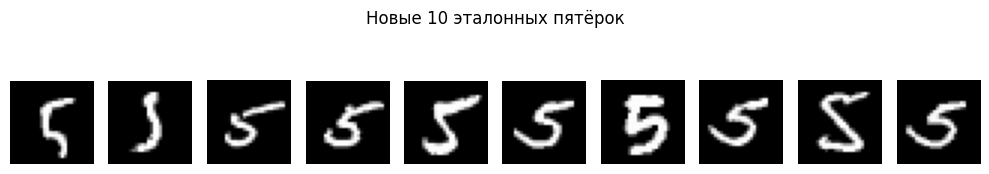

In [5]:
def show_digit_row(images, title):
    # Выводим выбранные изображения
    plt.figure(figsize=(10, 2))
    for pos, image in enumerate(images):
        plt.subplot(1, len(images), pos + 1)
        plt.imshow(image.reshape(28, 28), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


target_fives = X_train[REFERENCE_FIVE_IDS]
show_digit_row(target_fives, "Новые 10 эталонных пятёрок")

In [6]:
def build_target_set(source_data, templates, seed):
    # Для каждого изображения выбираем случайную пятёрку
    rng = np.random.default_rng(seed)
    template_numbers = rng.integers(0, len(templates), size=len(source_data))
    return templates[template_numbers]


y_train_target = build_target_set(X_train, target_fives, RANDOM_STATE)
y_test_target = build_target_set(X_test, target_fives, RANDOM_STATE + 1)

print(f"Форма обучающих входов: {X_train.shape}")
print(f"Форма обучающих ответов: {y_train_target.shape}")

Форма обучающих входов: (5421, 28, 28, 1)
Форма обучающих ответов: (5421, 28, 28, 1)


In [7]:
def make_autoencoder(input_shape=IMG_SHAPE):
    input_img = Input(shape=input_shape, name="input_five")

    x = Conv2D(32, (3, 3), padding="same", activation="relu")(input_img)
    x = BatchNormalization()(x)

    x = Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    latent_vector = Dense(32, activation="relu", name="latent_vector")(x)

    # Декодер восстанавливает изображение в виде одной из пятёрок
    x = Dense(7 * 7 * 64, activation="relu")(latent_vector)
    x = Reshape((7, 7, 64))(x)

    x = Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    output_img = Conv2D(1, (3, 3), padding="same", activation="sigmoid", name="output_five")(x)

    model = Model(input_img, output_img, name="five_style_autoencoder")
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

    return model


autoencoder = make_autoencoder()

print(f"Размер входа: {autoencoder.input_shape[1:]}")
print(f"Размер выхода: {autoencoder.output_shape[1:]}")
print(f"Размеры совпадают: {autoencoder.input_shape[1:] == autoencoder.output_shape[1:]}")

Размер входа: (28, 28, 1)
Размер выхода: (28, 28, 1)
Размеры совпадают: True


In [8]:
autoencoder.summary()

Model: "five_style_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_five (InputLayer)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_five (Conv2D)            │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,601 (2.37 MB)

 Trainable params: 621,089 (2.37 MB)

 Non-trainable params: 512 (2.00 KB)

In [9]:
print("Запуск обучения автокодировщика")

history = autoencoder.fit(
    X_train,
    y_train_target,
    epochs=15,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, y_test_target),
    verbose=1
)

train_mse = history.history["loss"][-1]
print(f"Итоговая MSE на обучающей выборке: {train_mse:.5f}")

if train_mse < 0.05:
    print("Условие MSE < 0.05 выполнено.")
else:
    print("MSE выше 0.05. Для улучшения можно увеличить число эпох")

Запуск обучения автокодировщика
Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - loss: 0.0936 - val_loss: 0.0818
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0728 - val_loss: 0.0773
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0717 - val_loss: 0.0792
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0710 - val_loss: 0.0781
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0700 - val_loss: 0.0745
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0686 - val_loss: 0.0712
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0673 - val_loss: 0.0702
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0638 - val_loss: 0.0632
Epoch 9/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0554 - val_loss: 0.0605
Epoch 10/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0508 - val_loss: 0.0613
Epoch 11/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0452 - val_loss: 0.0607
Epoch 12/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 

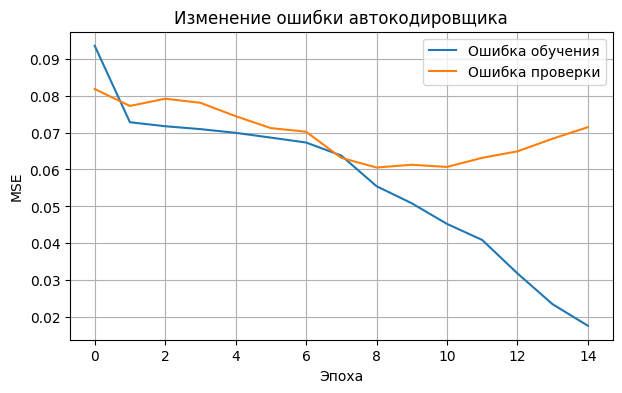

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Ошибка обучения")
plt.plot(history.history["val_loss"], label="Ошибка проверки")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Изменение ошибки автокодировщика")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


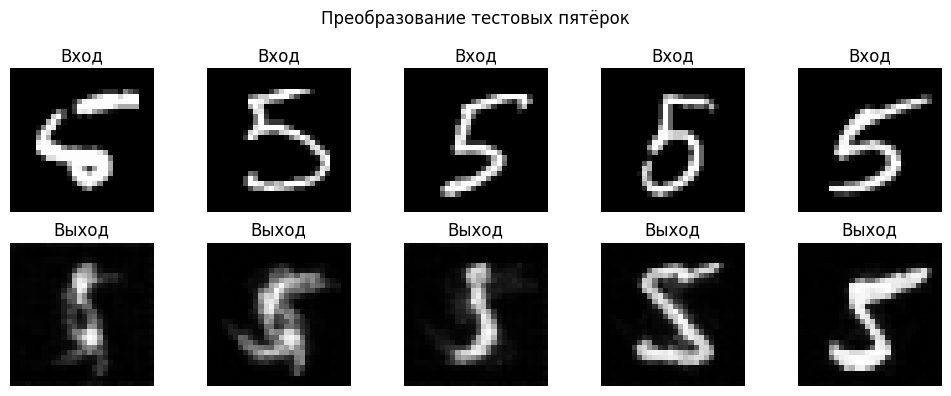

In [11]:
def compare_original_and_generated(model, source_images, count=5):
    # Сравниваем исходные тестовые пятёрки и результат
    generated = model.predict(source_images[:count])

    plt.figure(figsize=(10, 4))
    for i in range(count):
        plt.subplot(2, count, i + 1)
        plt.imshow(source_images[i].reshape(28, 28), cmap="gray")
        plt.title("Вход")
        plt.axis("off")

        plt.subplot(2, count, i + 1 + count)
        plt.imshow(generated[i].reshape(28, 28), cmap="gray")
        plt.title("Выход")
        plt.axis("off")

    plt.suptitle("Преобразование тестовых пятёрок")
    plt.tight_layout()
    plt.show()


compare_original_and_generated(autoencoder, X_test, count=5)